# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q6: Answers**

1. We use them for analysis because they can accomodate for situations where the outcomes need to be restricted further than a typical numeric value between neg and pos infinities. This means we can analyze more problems and find trends and patterns that are atypical.

2. They are effective because they help determine the optimal b that help maximizes the likelihood function. 

3. True, because it models log-odd of an outcome as a linear combo of input features, and also in the slide deck, it's under General Linear Models lol

4. False, it's literally made for binary outcomes of 0 or 1 and help gives us a probability of either outcome. 

5. Uhhhhh no, it represents the change of the log-odds of an outcome, not the predicted value.

6. FALSE! logisitic regression is a linear model!

7. False, log reg is best suited for classification while the OG linear model is better for continuous outcomes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


/var/folders/z7/yc1k0q6x25d9r9spfmyv7hwm0000gn/T/ipykernel_14587/772401543.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Age at enrollment']] = scaler.fit_transform(X[['Age at enrollment']])


Logistic regression coefficients:
Debtor                     0.527192
Tuition fees up to date   -2.605566
Scholarship holder        -1.242268
Age at enrollment          2.641673
dtype: float64
Debtor predicts higher dropout probability, Scholarship holder predicts lower dropout probability, Age at enrollment predicts higher dropout probability, and being up to date on tuition reduces dropout risk


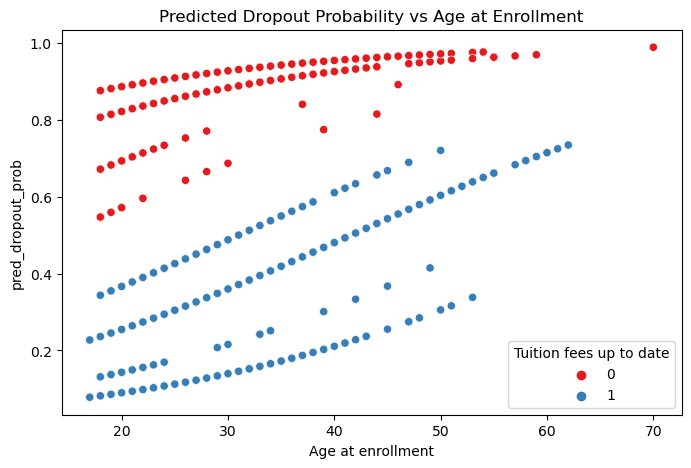

It seems like the age that being up to date on tuition that seem to reduce the probability of dropout is around 20 years old
Being up to date on tuition changes predicted dropout probability by  -0.6180967733617647
Confusion matrix: [[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


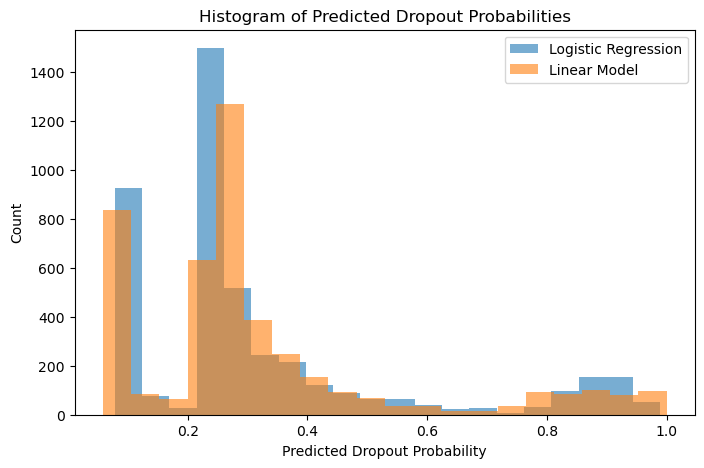

Multinomial confusion matrix:
 [[1054  367    0]
 [ 146 2063    0]
 [ 280  514    0]]
[[0.68038081 0.21052482 0.10909436]
 [0.69583605 0.14578475 0.1583792 ]
 [0.95305345 0.04113476 0.00581179]
 [0.11783041 0.17697916 0.70519043]
 [0.18422783 0.21265115 0.60312102]]
Predicted classes: ['Dropout' 'Graduate']
Classes with nonzero predicted probabilities: ['Dropout' 'Enrolled' 'Graduate']


In [21]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelBinarizer, MinMaxScaler


cols = [
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment',
    'Curricular units 1st sem (approved)', 'Target'
]
data = pd.read_csv('./data/data.csv', sep=';')
data = data[cols]
data = data.dropna()
binary_target = data['Target'].map(lambda x: 1 if x == 'Dropout' else 0)
data['Dropout'] = binary_target

#2
scaler = MinMaxScaler()
X = data[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
X[['Age at enrollment']] = scaler.fit_transform(X[['Age at enrollment']])
y = data['Dropout']
logreg = LogisticRegression(penalty=None, max_iter=1000)
logreg.fit(X, y)
coefs = pd.Series(logreg.coef_[0], index=X.columns)
print('Logistic regression coefficients:')
print(coefs)
print('Debtor predicts higher dropout probability, Scholarship holder predicts lower dropout probability, Age at enrollment predicts higher dropout probability, and being up to date on tuition reduces dropout risk')

#3
probs = logreg.predict_proba(X)[:, 1]
data['pred_dropout_prob'] = probs
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age at enrollment', y='pred_dropout_prob', hue='Tuition fees up to date', data=data, palette='Set1')
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.show()
diff = mean_by_tuition[1] - mean_by_tuition[0]
print('It seems like the age that being up to date on tuition that seem to reduce the probability of dropout is around 20 years old')
print('Being up to date on tuition changes predicted dropout probability by ', diff)

#4
preds = logreg.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print('Confusion matrix:', cm)
print(f'Accuracy: {acc}')

#5
linreg = LinearRegression()
linreg.fit(X, y)
probs_lin = linreg.predict(X)
probs_lin = np.clip(probs_lin, 0, 1)
plt.figure(figsize=(8,5))
plt.hist(probs, bins=20, alpha=0.6, label='Logistic Regression')
plt.hist(probs_lin, bins=20, alpha=0.6, label='Linear Model')
plt.xlabel('Predicted Dropout Probability')
plt.ylabel('Count')
plt.title('Histogram of Predicted Dropout Probabilities')
plt.legend()
plt.show()

#6
#based on the historgram, students that are not up to date on tuition, do not have shcolarhips and students that are younger in enrollment have a higher risk of dropout.
#to help them, there should be more finanical support for them and help them be up to date with their tuitions. 

#7
multi_X = data[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
multi_y = data['Target']
multi_logreg = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_logreg.fit(multi_X, multi_y)
preds_multi = multi_logreg.predict(multi_X)
cm_multi = confusion_matrix(multi_y, preds_multi, labels=['Dropout', 'Graduate', 'Enrolled'])
print('Multinomial confusion matrix:\n', cm_multi)
probs_multi = multi_logreg.predict_proba(multi_X)
print(probs_multi[:5])
print('Predicted classes:', np.unique(preds_multi))
print('Classes with nonzero predicted probabilities:', multi_logreg.classes_)

#predict_proba does predict each class as all students have a nonzero prob for the three classes while for .predict(), it leaves out Enrolled. 

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

Logistic regression coefficients:
Bilirubin      -9.705112
Edema_S        -0.578254
Edema_Y        -2.859242
Drug_Placebo    0.252686
dtype: float64


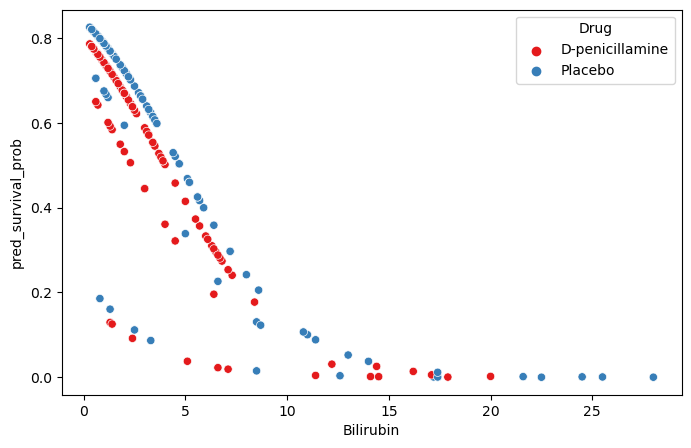

The lower vlaues of bilirbin seems to increase patient survivial rate
On average, Placebo changes survival probability by 0.021782450226586536
Confusion matrix: [[ 57  68]
 [ 14 173]]
0.7371794871794872


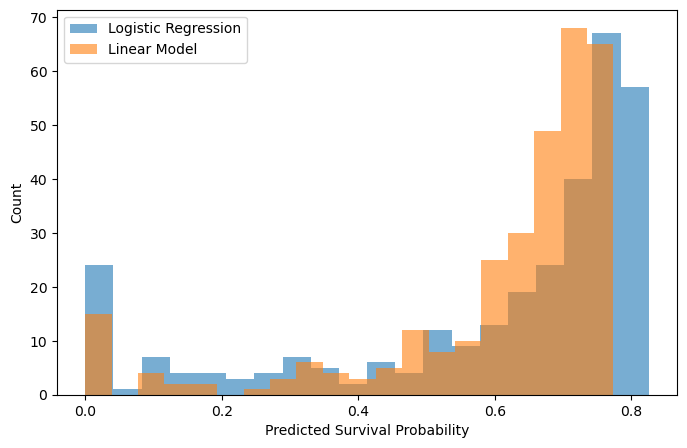

Stage confusion matrix:
 [[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]
Predicted classes: [3. 4.]
[[0.01314008 0.05124103 0.14592501 0.78969389]
 [0.05971993 0.24388829 0.4047306  0.29166118]
 [0.02521624 0.16637125 0.39339728 0.41501523]
 [0.0247866  0.16369837 0.39197054 0.41954449]
 [0.05503051 0.22601855 0.40317269 0.31577825]]
Classes with nonzero predicted probabilities: [1. 2. 3. 4.]


In [22]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
data = pd.read_csv('./data/cirrhosis.csv')
data = data[cols]
data = data.dropna()
data['Alive'] = data['Status'].map(lambda x: 1 if x in ['C', 'CL'] else 0)
X = data[['Bilirubin', 'Edema', 'Drug']]
X = pd.get_dummies(X, columns=['Edema', 'Drug'], drop_first=True)
scaler = MinMaxScaler()
X[['Bilirubin']] = scaler.fit_transform(X[['Bilirubin']])
y = data['Alive']

#2
logreg = LogisticRegression(penalty=None, max_iter=1000)
logreg.fit(X, y)
coefs = pd.Series(logreg.coef_[0], index=X.columns)
print('Logistic regression coefficients:')
print(coefs)
#The drug (Placebo) doesn't really improve survival probability. 
# Higher bilirubin predicts much lower survival probability.
# Survival prob decreases as edema severity increases.

#3
probs = logreg.predict_proba(X)[:, 1]
data['pred_survival_prob'] = probs
plt.figure(figsize=(8,5))
sns.scatterplot(x='Bilirubin', y='pred_survival_prob', hue='Drug', data=data, palette='Set1')
plt.show()
mean_by_drug = data.groupby('Drug')['pred_survival_prob'].mean()
print('The lower vlaues of bilirbin seems to increase patient survivial rate')
diff = mean_by_drug['Placebo'] - mean_by_drug['D-penicillamine']
print(f'On average, Placebo changes survival probability by {diff}')

#4
preds = logreg.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print('Confusion matrix:', cm)
print(acc)

#5
linreg = LinearRegression()
linreg.fit(X, y)
probs_lin = linreg.predict(X)
probs_lin = np.clip(probs_lin, 0, 1)
plt.figure(figsize=(8,5))
plt.hist(probs, bins=20, alpha=0.6, label='Logistic Regression')
plt.hist(probs_lin, bins=20, alpha=0.6, label='Linear Model')
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Count')
plt.legend()
plt.show()
#about the same perfomance although log reg does seem to result in higher predicted survivial probability

#6
X_stage = data[['Bilirubin', 'Edema']]
X_stage = pd.get_dummies(X_stage, columns=['Edema'], drop_first=True)
X_stage[['Bilirubin']] = scaler.fit_transform(X_stage[['Bilirubin']])
y_stage = data['Stage']
logreg_stage = LogisticRegression(multi_class='multinomial', max_iter=1000)
logreg_stage.fit(X_stage, y_stage)
preds_stage = logreg_stage.predict(X_stage)
cm_stage = confusion_matrix(y_stage, preds_stage)
print('Stage confusion matrix:\n', cm_stage)
print('Predicted classes:', np.unique(preds_stage))
probs_stage = logreg_stage.predict_proba(X_stage)
print(probs_stage[:5])
print('Classes with nonzero predicted probabilities:', logreg_stage.classes_)
#hard classification only predicts stages 3 and 4 and the predcited proba predicts every stage. 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

![homework glm, question 4 answers](images/glm.jpeg)